In [1]:
import json
import matplotlib.pyplot as plt
import io, h5py, zipfile
import numpy as np
from tqdm import tqdm
import os
import mienc.support as ms
from mienc import Corrector, NonLinearEstimator
import pandas as pd
from scipy.signal import hilbert
from scipy.io import loadmat, savemat
import multiprocessing as mp
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

/home/raffaelli/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [2]:
bands={i:b for i, b in enumerate([[ 1.,  4.], [ 4.,  8.], [ 8., 12.], [12., 15.], [15., 18.], [18., 30.], [30., 44.], [12., 30.], [ 1., 40.]], start=1)}



shadow = np.empty((1120, 195, 50, 9))
for subject in tqdm(range(50), total=50):
    tmp_subj = np.empty((1120, 195, 9))
    with zipfile.PyZipFile("../NonLinearityData/EEG_el_so_BLP_20230714.zip") as zip_file:
        archive = h5py.File(io.BytesIO(zip_file.read(f"Sub_{subject+1}/EEG_bands.mat")))
            
    for band in range(1,10):
        band_data = archive[archive["EEG_bands"][0,band-1]]
        tmp_pieces = []
        tot_len = 0

        for i in range(band_data.shape[0]):
            this_piece = archive[band_data[i,0]]
            tmp = ms.surrogate(this_piece)
            z = hilbert(tmp, axis=0)
            power = np.absolute(z)
            full_samp = power.shape[0]//125
            extra = full_samp*125 < power.shape[0]
            dsp = np.zeros((full_samp+extra, power.shape[1]))
            dsp[:full_samp,:] = np.average(np.reshape(power[:full_samp*125],(-1,125,power.shape[1])),1)
            if extra:
                dsp[-1,:] = np.average(power[full_samp*125:,:],0)
            tmp_pieces.append(dsp.copy())
            tot_len += dsp.shape[0]
            if tot_len > 1120:
                break
        tmp_subj[:,:,band-1]=np.concatenate(tmp_pieces)[:1120,:]
    shadow[:,:,subject,:]=tmp_subj

 10%|█         | 5/50 [15:29<2:31:04, 201.43s/it]

In [ ]:
for band in range(1,10):
    savemat(f"/home/raffaelli/NonLinearityData/EEG_el_so_BLP_NEW/NEW_electrodeBLP_fixedTime_avg1_shadow_band{band}.mat", {"BLP":shadow[:,:,:,band-1]})

In [29]:
from scipy.signal import hilbert
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

mat = loadmat("/home/raffaelli/NonLinearity/NonLinearityData/EEG_el_so_BLP_NEW/NEW_EEG_fixedTime_band1.mat")["EEG"][:,:,0]
tr = hilbert(mat[:,0])

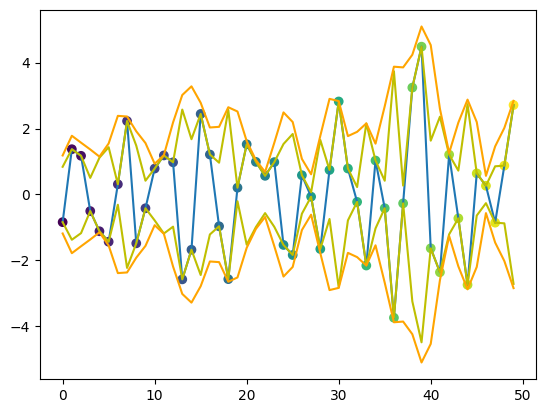

In [41]:
plt.plot(mat[:50,0])
plt.scatter(np.arange(50), mat[:50,0], c=np.arange(50))
plt.plot(np.absolute(mat[:50, 0]), color="y")
plt.plot(-np.absolute(mat[:50, 0]), color="y")
plt.plot(np.absolute(tr[:50]), color="orange")
plt.plot(-np.absolute(tr[:50]), color="orange")
plt.show()

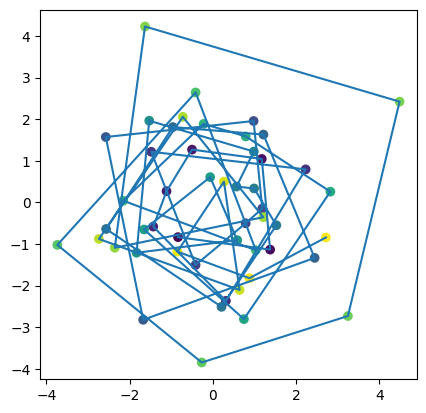

In [36]:
plt.plot(np.real(tr[:50]), np.imag(tr[:50]))
plt.scatter(np.real(tr[:50]), np.imag(tr[:50]), c=np.arange(50))
plt.gca().set_aspect(1)
plt.show()